# Mental Health in Technology-related Jobs
Unsupervised learning case study: PCA + K-Means clustering of the OSMI *Mental Health in Tech 2016* survey.

Course: DLBDSMLUSL01 - Machine Learning: Unsupervised Learning and Feature Engineering (Task 1)

Author: Biama Baqqali

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Environment and data

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}, numpy: {np.__version__}")

df_raw = pd.read_csv("survey_raw.csv")
print(f"Raw survey shape: {df_raw.shape}")
df_raw.head(3)

Python: 3.11.15
pandas: 3.0.5, numpy: 2.4.6
Raw survey shape: (1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always


### Scope: company employees only
The questionnaire branches after *"Are you self-employed?"*: only respondents employed by a company are subsequently asked about employer-provided benefits, wellness communication and leave policy. Since the HR program in this case study targets a company's own staff, self-employed respondents are excluded.

In [3]:
df = df_raw[df_raw["Are you self-employed?"] == 0].copy()
print(f"Respondents (total): {len(df_raw)}")
print(f"Respondents (employees analysed): {len(df)}")

Respondents (total): 1433
Respondents (employees analysed): 1146


## Data cleaning and feature engineering
The survey mixes several near-synonymous answer scales for the same underlying construct (agreement / awareness / ease). These are consolidated onto a single 0-1 ordinal scale so that Euclidean-distance methods (PCA, K-Means) treat comparable answers consistently across questions. Age outliers and free-text gender are also cleaned.

In [4]:
def yes_no_maybe(series):
    """Ordinal-encode 3/4-level attitude & policy questions onto 0-1."""
    positive = {"Yes", "Yes, they all did", "Yes, I was aware of all of them",
                "Very easy", "Very open", "I know some", "Yes, I know several"}
    negative = {"No", "No, none did", "N/A (not currently aware)",
                "Very difficult", "Not open at all", "No, I don't know any"}

    def _map(v):
        if pd.isna(v):
            return 0.5
        if v in positive:
            return 1.0
        if v in negative:
            return 0.0
        return 0.5  # neutral / uncertain answers (Maybe, I don't know, ...)

    return series.apply(_map)


def company_size_ordinal(series):
    mapping = {"1-5": 1, "6-25": 2, "26-100": 3, "100-500": 4,
               "500-1000": 5, "More than 1000": 6}
    return series.map(mapping)


def remote_ordinal(series):
    return series.map({"Never": 0, "Sometimes": 1, "Always": 2})


def clean_gender(series):
    def _map(v):
        if pd.isna(v):
            return "Other/Unknown"
        v = str(v).strip().lower()
        if v in {"male", "m", "man", "cis male", "cis man"}:
            return "Male"
        if v in {"female", "f", "woman", "cis female", "cis woman"}:
            return "Female"
        return "Other/Unknown"
    return series.apply(_map)


def clean_age(series):
    s = pd.to_numeric(series, errors="coerce")
    s = s.where((s >= 18) & (s <= 75))  # drop data-entry errors (3, 15, 323, ...)
    return s.fillna(s.median())

In [5]:
features = pd.DataFrame(index=df.index)

# --- HR / employer policy indicators -----------------------------------
features["benefits"] = yes_no_maybe(df["Does your employer provide mental health benefits as part of healthcare coverage?"])
features["knows_options"] = yes_no_maybe(df["Do you know the options for mental health care available under your employer-provided coverage?"])
features["wellness_discussed"] = yes_no_maybe(df["Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?"])
features["resources_offered"] = yes_no_maybe(df["Does your employer offer resources to learn more about mental health concerns and options for seeking help?"])
features["anonymity_protected"] = yes_no_maybe(df["Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?"])
features["leave_ease"] = yes_no_maybe(df["If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:"])
features["employer_takes_seriously"] = yes_no_maybe(df["Do you feel that your employer takes mental health as seriously as physical health?"])

# --- Personal comfort / perceived-stigma indicators ---------------------
features["fear_negative_mh"] = 1 - yes_no_maybe(df["Do you think that discussing a mental health disorder with your employer would have negative consequences?"])
features["comfort_coworkers"] = yes_no_maybe(df["Would you feel comfortable discussing a mental health disorder with your coworkers?"])
features["comfort_supervisor"] = yes_no_maybe(df["Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?"])
features["observed_negative_consequences"] = 1 - yes_no_maybe(df["Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?"])

# --- Personal mental-health history --------------------------------------
features["family_history"] = yes_no_maybe(df["Do you have a family history of mental illness?"])
features["past_disorder"] = yes_no_maybe(df["Have you had a mental health disorder in the past?"])
features["current_disorder"] = yes_no_maybe(df["Do you currently have a mental health disorder?"])
features["sought_treatment"] = df["Have you ever sought treatment for a mental health issue from a mental health professional?"].fillna(0).astype(float)

# --- Firmographics & demographics ----------------------------------------
features["company_size"] = company_size_ordinal(df["How many employees does your company or organization have?"])
features["company_size"] = features["company_size"].fillna(features["company_size"].median())
features["is_tech_company"] = df["Is your employer primarily a tech company/organization?"].fillna(0.5).astype(float)
features["remote_work"] = remote_ordinal(df["Do you work remotely?"])
features["age"] = clean_age(df["What is your age?"])

gender = clean_gender(df["What is your gender?"])
features = pd.concat([features, pd.get_dummies(gender, prefix="gender")], axis=1)

print(f"Engineered feature matrix: {features.shape}")
features.head()

Engineered feature matrix: (1146, 22)


,benefits,knows_options,wellness_discussed,resources_offered,anonymity_protected,leave_ease,employer_takes_seriously,fear_negative_mh,comfort_coworkers,comfort_supervisor,...,past_disorder,current_disorder,sought_treatment,company_size,is_tech_company,remote_work,age,gender_Female,gender_Male,gender_Other/Unknown
0,0.5,0.5,0.0,0.0,0.5,1.0,0.5,1.0,0.5,1.0,...,1.0,0.0,0.0,3,1.0,1,39.0,False,True,False
1,0.0,1.0,1.0,1.0,1.0,0.5,1.0,1.0,0.5,1.0,...,1.0,1.0,1.0,2,1.0,0,29.0,False,True,False
2,0.0,0.5,0.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,...,0.5,0.0,1.0,2,1.0,2,38.0,False,True,False
4,1.0,1.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,...,1.0,1.0,1.0,2,0.0,1,43.0,True,False,False
5,1.0,0.5,0.0,1.0,1.0,0.5,0.0,0.0,0.5,1.0,...,0.0,1.0,1.0,6,1.0,1,42.0,False,True,False


## Standardisation and dimensionality reduction (PCA)

Components needed for 80% variance: 12 (of 22 features)


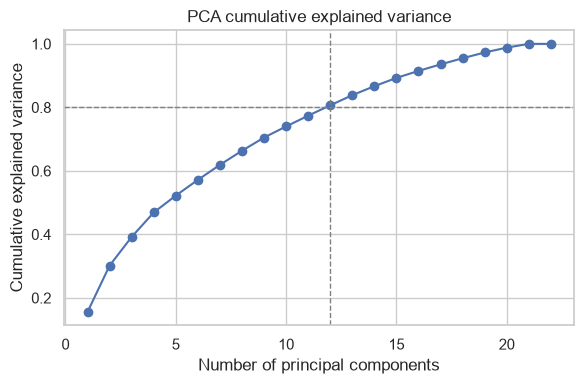

In [6]:
X = features.astype(float)
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = int(np.searchsorted(cum_var, 0.80) + 1)
print(f"Components needed for 80% variance: {n_components_80} (of {X.shape[1]} features)")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.80, color="grey", linestyle="--", linewidth=1)
plt.axvline(n_components_80, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.tight_layout()
plt.show()

In [7]:
pca = PCA(n_components=n_components_80, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_scaled)
print(f"2D projection explains {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance "
      f"(PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%)")

2D projection explains 30.2% of variance (PC1=15.6%, PC2=14.6%)


## Choosing k: elbow method and silhouette score

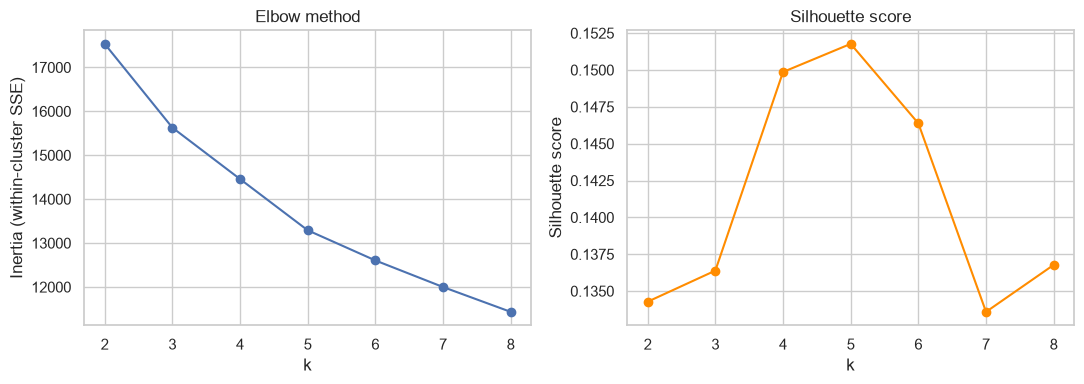

Selected k = 5 (highest silhouette score = 0.152)


In [8]:
k_range = range(2, 9)
inertias, sils = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set(xlabel="k", ylabel="Inertia (within-cluster SSE)", title="Elbow method")
axes[1].plot(list(k_range), sils, marker="o", color="darkorange")
axes[1].set(xlabel="k", ylabel="Silhouette score", title="Silhouette score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sils))]
print(f"Selected k = {best_k} (highest silhouette score = {max(sils):.3f})")

## Final K-Means clustering

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels = kmeans.fit_predict(X_pca)
features["cluster"] = labels
print(f"Final silhouette score: {silhouette_score(X_pca, labels):.3f}")
features["cluster"].value_counts().sort_index()

Final silhouette score: 0.152


cluster
0    243
1    329
2    196
3    331
4     47
Name: count, dtype: int64

### Clusters in principal-component space

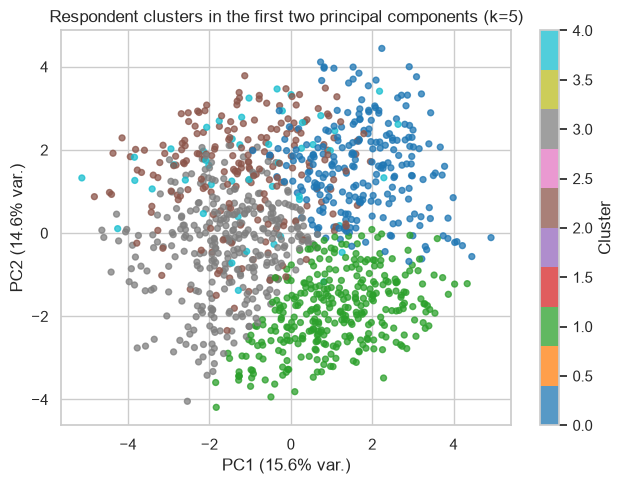

In [10]:
plt.figure(figsize=(6.5, 5))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=labels, cmap="tab10", s=18, alpha=0.75)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title(f"Respondent clusters in the first two principal components (k={best_k})")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

### Cluster profiles

In [11]:
profile_cols = [c for c in features.columns if not c.startswith("gender_") and c != "cluster"]
profile = features.groupby("cluster")[profile_cols].mean().round(2)
profile["n_respondents"] = features.groupby("cluster").size()
profile["share_%"] = (profile["n_respondents"] / len(features) * 100).round(1)
profile

,benefits,knows_options,wellness_discussed,resources_offered,anonymity_protected,leave_ease,employer_takes_seriously,fear_negative_mh,comfort_coworkers,comfort_supervisor,...,family_history,past_disorder,current_disorder,sought_treatment,company_size,is_tech_company,remote_work,age,n_respondents,share_%
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.90,0.75,0.62,0.76,0.80,0.69,0.77,0.84,0.69,0.85,...,0.70,0.78,0.66,0.80,4.23,0.72,1.01,35.21,243,21.2
1,0.55,0.32,0.21,0.32,0.60,0.63,0.61,0.74,0.52,0.62,...,0.23,0.11,0.09,0.07,3.54,0.83,0.98,32.39,329,28.7
2,0.68,0.54,0.14,0.36,0.57,0.44,0.44,0.45,0.36,0.44,...,0.74,0.78,0.69,0.80,3.62,0.74,0.93,32.89,196,17.1
3,0.51,0.40,0.07,0.24,0.48,0.41,0.31,0.36,0.25,0.29,...,0.67,0.78,0.66,0.73,3.65,0.76,0.76,33.77,331,28.9
4,0.67,0.49,0.23,0.33,0.61,0.51,0.45,0.55,0.49,0.51,...,0.78,0.84,0.73,0.81,3.66,0.85,0.83,30.17,47,4.1


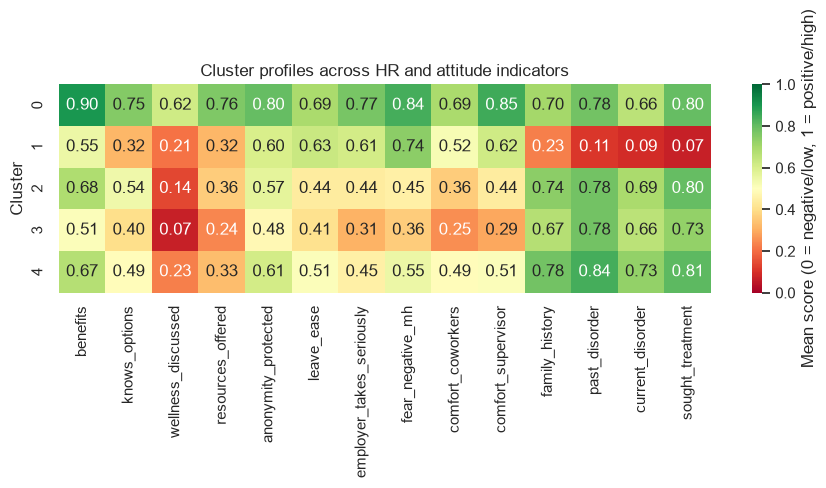

In [12]:
heat_cols = ["benefits", "knows_options", "wellness_discussed", "resources_offered",
             "anonymity_protected", "leave_ease", "employer_takes_seriously",
             "fear_negative_mh", "comfort_coworkers", "comfort_supervisor",
             "family_history", "past_disorder", "current_disorder", "sought_treatment"]

plt.figure(figsize=(9, 4.5))
sns.heatmap(profile[heat_cols], annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "Mean score (0 = negative/low, 1 = positive/high)"})
plt.title("Cluster profiles across HR and attitude indicators")
plt.xlabel("")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

## Key findings
- The clusters with the **lowest employer support** (benefits, awareness, formal wellness communication) also show the **lowest comfort** discussing mental health with coworkers or supervisors, despite substantial personal mental-health relevance in those groups — these are the primary targets for the HR program.
- The best-supported cluster (highest benefits/comfort scores, larger companies) still shows a high fear of negative consequences, indicating that formal policy alone does not remove stigma.
- A cluster with almost no personal mental-health history still reports a high fear of negative consequences, showing that stigma perception is not limited to personally affected employees.
- The silhouette score of the final solution is modest, which is expected for largely ordinal/attitudinal survey data: clusters should be read as tendencies rather than sharply separated types.